## Inference on the Montbriò model with JAX implementation

In [16]:
import sys
import os
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)

In [17]:
import warnings
import time
import numpy as np
import seaborn as sns
import jax
jax.config.update("jax_platform_name", "cpu")
# jax.config.update("jax_platform_name", "cuda")

import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from importlib import reload
import pandas as pd
from scipy.stats import ks_2samp, entropy
import logging
import utils
from FCD_jax import *
import mpr_jax
mpr_jax=reload(mpr_jax)

warnings.simplefilter("ignore")

In [3]:
import arviz as az
# import graphviz
az.style.use("arviz-darkgrid")
import seaborn as sns
#optimization algorithm we will try before bayesian inference
import scipy
from scipy.optimize import differential_evolution
#numpyro is a jax-based package for inference
import numpyro as npr
from numpyro import sample, plate, handlers
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_sample

In [4]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

In [5]:
@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [6]:
def plot(rv_t, r, v, bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

In [7]:
def plot_bold(bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(1, 1, figsize=(12, 2))
    ax.plot(bold_t, bold_d, lw=0.1)
    ax.set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

In [8]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(datapath+"/weights.txt", delimiter=None)
nn = len(weights)
weights = jnp.array(weights)/jnp.max(weights)

In [9]:
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 300000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0,
          "seed":42
          }

In [10]:
g=0.33
rv_t, r, v, bold_t, bold_d_obs = wrapper(g, params)

wrapper took 23.99 seconds


In [11]:
params_labels = ['$G$']
my_var_name = ['G']

In [12]:
theta_true = np.array([g])

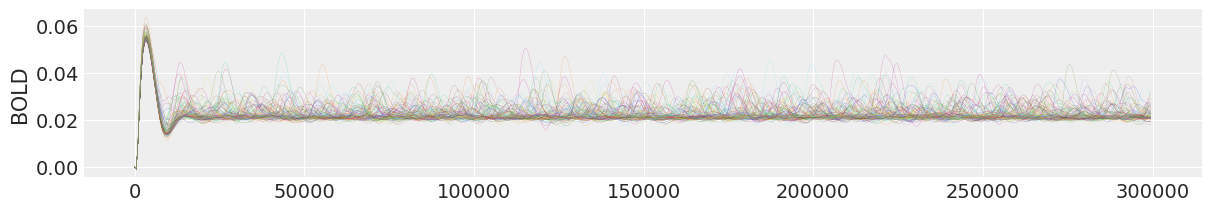

In [13]:
plot_bold(bold_d_obs, bold_t, g);

In [14]:
wwidth = 30  # must be < 60
maxNwindows = 200
olap = 0.94

In [45]:
bold_d_obs_T = bold_d_obs.T
FC_obs = get_fc(bold_d_obs_T)
FCD_obs, FCvec, _ = extract_FCD(bold_d_obs_T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)

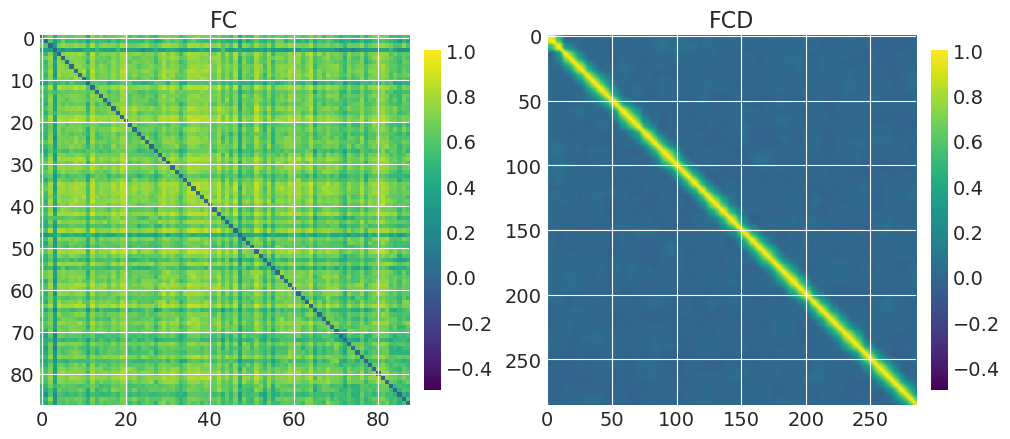

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

matrices = [FC_obs, FCD_obs]
titles = ["FC", "FCD"]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, vmin=-0.5, vmax=1, cmap='viridis')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#plt.tight_layout()
plt.show()

## Inference with optimization

#### Define the losses (to quantify the distance between the observed data and the simulated ones)

In [47]:
# flatten FC_obs and FCD_obs
FC_obs_flat = np.ravel(FC_obs)
FCD_obs_flat = np.ravel(FCD_obs)

In [48]:
from importlib import reload
mpr_jax=reload(mpr_jax)

In [49]:
sde_sim = mpr_jax.MPR_sde.create(params)

In [50]:
def loss_fc_ks(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = FCD_jax.get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    # Convert to NumPy for scipy functions
    fc_sim_flat_np = np.array(fc_sim_flat)
    obs_flat_np = np.array(FC_obs_flat)
    
    # KS distance
    KS = ks_2samp(obs_flat_np, fc_sim_flat_np)[0]
    return KS

In [51]:
def loss_fcd_ks(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fcd_sim, _, _ = FCD_jax.extract_FCD(bold_d_sim.T)
    fcd_sim_flat = jnp.ravel(fcd_sim)
    
    # Convert to NumPy for scipy functions
    fcd_sim_flat_np = np.array(fcd_sim_flat)
    obs_flat_np = np.array(FCD_obs_flat)
    
    # KS distance
    KS = ks_2samp(obs_flat_np, fcd_sim_flat_np)[0]
    return KS

In [52]:
def loss_fc_kl(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = FCD_jax.get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    # Convert to NumPy for scipy functions
    fc_sim_flat_np = np.array(fc_sim_flat)
    obs_flat_np = np.array(FC_obs_flat)

    # KL divergence
    eps = 1e-8
    bins = 50
    
    # Histogram for observed data
    p_hist, edges = np.histogram(obs_flat_np, bins=bins, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    
    # Histogram for the single simulated dataset
    q_hist, _ = np.histogram(fc_sim_flat_np, bins=edges, density=True)
    q = (q_hist + eps) / (q_hist + eps).sum()
    
    # KL divergence
    KL = entropy(p, q)

    return KL

In [53]:
def loss_fcd_kl(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fcd_sim = FCD_jax.extract_FCD(bold_d_sim.T)
    fcd_sim_flat, _, _ = jnp.ravel(fcd_sim)
    
    # Convert to NumPy for scipy functions
    fcd_sim_flat_np = np.array(fcd_sim_flat)
    obs_flat_np = np.array(FCD_obs_flat)

    # KL divergence
    eps = 1e-8
    bins = 50
    
    # Histogram for observed data
    p_hist, edges = np.histogram(obs_flat_np, bins=bins, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    
    # Histogram for the single simulated dataset
    q_hist, _ = np.histogram(fcd_sim_flat_np, bins=edges, density=True)
    q = (q_hist + eps) / (q_hist + eps).sum()
    
    # KL divergence
    KL = entropy(p, q)
    
    return KL

#### Optimization step

In [24]:
def callback_function(intermediate_result, convergence=None): 
    trace_loss.append(intermediate_result[0])  
    trace_prms.append(intermediate_result[1:]) 

In [25]:
Niter = 1

def callback_function_params_only(xk, convergence=None):
    global Niter
    if convergence is None:
        logging.info('{0:4d}   {1: 3.6f}'.format(
            Niter,
            xk[0]))
    else:
        logging.info('{0:4d}   {1: 3.6f}   {6: 1.3f}'.format(
            Niter,
            xk[0],
            convergence))
    Niter += 1

In [26]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

In [28]:
maxiter = 1000 #it wa 1000
popsize = 5
callback = callback_function #or callbackfunction

In [ ]:
start_time = time.time()
res = differential_evolution(loss_fc_ks, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

In [64]:
res.x

array([0.33771205])

In [65]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fcd_ks = differential_evolution(loss_fcd_ks, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

Scipy DE took (sec): 24548.267315626144


In [66]:
res_fcd_ks.x

array([0.07711231])

In [67]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fc_kl = differential_evolution(loss_fc_kl, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

NameError: name 'mixiter' is not defined

In [ ]:
res_fc_kl.x

In [ ]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fcd_kl = differential_evolution(loss_fcd_kl, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

In [ ]:
res_fcd_kl

## Bayesian Inference

In [54]:
scale = 1 

In [56]:
def model_fc(sde_sim,FC_obs_flat):
    G = npr.sample('G',dist.HalfNormal(scale=scale))
    param_samples = [G]
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    """Converting to NumPy for scipy functions will fail. Try with JAX arrays first to bypass Tracer errors."""

    # Likelihood
    with npr.plate("data", size=FC_obs_flat.shape[0]):
        npr.sample("fc_obs", 
                   dist.Normal(loc=fc_sim_flat, scale=0.1),  # adjust noise scale
                   obs=FC_obs_flat)

In [57]:
with npr.handlers.seed(rng_seed=1):
    trace = npr.handlers.trace(model_fc).get_trace(sde_sim, FC_obs_flat)
print(npr.util.format_shapes(trace))

Trace Shapes:       
 Param Sites:       
Sample Sites:       
       G dist      |
        value      |
   data plate 7744 |
  fc_obs dist 7744 |
        value 7744 |


#### Prior predictive checks

In [58]:
rng_key = jax.random.PRNGKey(0) 

In [59]:
n_prior = 10 # number of samples from prior

prior_predictive = Predictive(model_fc, num_samples=n_prior)

_, rng_key = jax.random.split(rng_key)
prior_predictions = prior_predictive(rng_key, sde_sim, FC_obs_flat)